In [5]:
from DataLoader import DataLoader
from tara_preprocessing import get_just_ecog_data,get_electrode_normalized_loc
from tara_preprocessing import remove_duplicates, preprocessing,apply_car_function
from noah_production_funcs_2 import get_1_patient_locations
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm

In [6]:
from torch_geometric.datasets import TUDataset
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv,BatchNorm
from torch_geometric.nn import global_mean_pool,global_add_pool

In [7]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
ecogs_no_dups,xyz_no_dups = remove_duplicates(ecogs,xyz)
print('Removed duplicate electrodes')
xyz_clean, ecogs_cleaned = preprocessing(ecogs_no_dups,xyz_no_dups,notch_size=.05)
print("Done Preprocessing")

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [27]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader
from torch_geometric.utils import to_dense_adj
from sklearn.neighbors import NearestNeighbors

# ─── Config ───────────────────────────────────────────────────────────────────
win_size = 200
k = 10
hidden_dim = 64 
lr = 0.001
weight_decay = 1e-4 # L2 Regularization to help generalization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ─── Pre-calculate Patient Graphs ─────────────────────────────────────────────
# This avoids recalculating neighbors every single time a window is pulled
def precompute_graphs(patient_list, ecogs, xyz_coords, k_neighbors):
    graphs = {}
    for pat_idx in patient_list:
        locs = get_1_patient_locations(pat_idx, ecogs, xyz_coords)
        neighbors = NearestNeighbors(n_neighbors=k_neighbors).fit(locs)
        dists, idxs = neighbors.kneighbors(return_distance=True)

        all_edges, all_weights = [], []
        for node, (nbrs, ds) in enumerate(zip(idxs, dists)):
            for nbr, d in zip(nbrs, ds):
                all_edges.append([int(nbr), node]) #the first is the source in this one, the other is the target
                all_weights.append(d)
        graphs[pat_idx] = {
            'edges': np.array(all_edges).T,
            'weights': np.array(all_weights),
            'locs': locs
        }
    return graphs

# ─── New Dynamic Dataset ──────────────────────────────────────────────────────
class ECoGDataset(Dataset):
    def __init__(self, patient_list, ecogs, graphs, win_size, samples_per_epoch=200):
        self.patient_list = patient_list
        self.ecogs = ecogs
        self.graphs = graphs
        self.win_size = win_size
        self.samples_per_epoch = samples_per_epoch

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, idx):
        # 1. Pick a random patient
        pat_idx = random.choice(self.patient_list)
        data = self.ecogs[pat_idx]
        graph = self.graphs[pat_idx]

        # 2. Pick a random window
        start = random.randint(0, data.shape[0] - self.win_size - 1)
        window_data = data[start:start + self.win_size, :] # [T, N]

        # 3. Randomly select electrodes to hold out (mask)
        num_nodes = window_data.shape[1]
        list_held = np.random.choice(num_nodes, size=int(num_nodes/3), replace=False).tolist()

        held_temp = k*np.array(list_held) #starting index where the edges for this node are, then gets the next ten (its edges) #!SHOULD BE K BUT IDK WHAT THAT IS SO WHO KNOWS
        edges_held = (held_temp[:, None] + np.arange(k)).ravel() #gets all the edges by
        #remove from the edges and weights matrics the held out electrode ones 
        graph_egdes = np.delete(graph['edges'].copy(), edges_held, axis=1)
        graph_weights = np.delete(graph['weights'].copy(), edges_held)
        # 4. Construct point for tensorization
        # Hide target data in the input features
        features = window_data.copy()
        target = window_data[:, list_held].copy()

        point = {
            'features': features.T, # [N, T]
            'edges': graph_egdes,
            'weights': graph_weights,
            'locs': graph['locs'],
            'target': target.T # [Held_N, T]
        }
        return tensorize_point(point, self.win_size, list_held)

# ─── Tensorize & Adjacency Helpers ────────────────────────────────────────────
def tensorize_point(point, win_size, list_held):
    edges = torch.tensor(point['edges'], dtype=torch.long)
    edge_weights = torch.tensor(point['weights'], dtype=torch.float32)
    features = torch.tensor(point['features'], dtype=torch.float32)
    locs = torch.tensor(point['locs'], dtype=torch.float32)
    y = torch.tensor(point['target'], dtype=torch.float32)

    # Gaussian Kernel for weights
    sigma = 20.0
    edge_weights = torch.exp(-(edge_weights**2) / (2 * sigma**2))

    locs = locs / 100.0
    # Add this inside the training loop only (or in __getitem__)
    if model.training:
        # Increase jitter to 2% to make the model "work" for it
        locs = locs + (torch.randn_like(locs) * 0.02)

    # Normalize Visible Features
    visible = [i for i in range(features.shape[0]) if i not in list_held]
    for i in visible:
        features[i] = (features[i] - features[i].mean()) / features[i].std().clamp(min=1e-6)

    # Normalize Target
    y = (y - y.mean(dim=1, keepdim=True)) / y.std(dim=1, keepdim=True).clamp(min=1e-6)

    #if model.training:
        # 15% of working electrodes get zeroed out
        #drop_mask = (torch.rand(features.shape[0], 1) > 0.15).float()
        #features = features * drop_mask

    # Prepare X: [T, N, 4] -> (Signal + XYZ)
    x_signal = features.T.unsqueeze(-1)
    locs_expanded = locs.unsqueeze(0).expand(win_size, -1, -1)
    x = torch.cat([x_signal, locs_expanded], dim=-1)

    # Masking with Noise Token
    for elec in list_held:
        # Only overwrite index 0 (the signal)
        x[:, elec, 0] = torch.randn(win_size) * 0.02
        
    # Precompute Adjacency
    adj = to_dense_adj(edges, edge_attr=edge_weights, max_num_nodes=features.shape[0]).squeeze(0)
    deg_out_inv = 1.0 / adj.sum(dim=1).clamp(min=1)
    deg_in_inv  = 1.0 / adj.sum(dim=0).clamp(min=1)
    adj_out = (deg_out_inv.unsqueeze(1) * adj)
    adj_in  = (adj * deg_in_inv.unsqueeze(0))

    return {'x': x, 'y': y, 'adj_out': adj_out, 'adj_in': adj_in, 'elecs_held': list_held}

def collate_fn(batch):
    max_nodes = max(p['x'].shape[1] for p in batch)
    win_size, feat_dim = batch[0]['x'].shape[0], batch[0]['x'].shape[2]

    batch_x, batch_y, batch_adj_out, batch_adj_in, batch_masks = [], [], [], [], []

    for p in batch:
        n = p['x'].shape[1]
        pad = max_nodes - n

        batch_x.append(torch.cat([p['x'], torch.zeros(win_size, pad, feat_dim)], dim=1))

        y_padded = torch.zeros(max_nodes, win_size)
        y_padded[p['elecs_held']] = p['y']
        batch_y.append(y_padded)

        adj_o = torch.zeros(max_nodes, max_nodes)
        adj_o[:n, :n] = p['adj_out']
        batch_adj_out.append(adj_o)

        adj_i = torch.zeros(max_nodes, max_nodes)
        adj_i[:n, :n] = p['adj_in']
        batch_adj_in.append(adj_i)

        mask = torch.zeros(max_nodes, dtype=torch.bool)
        mask[p['elecs_held']] = True
        batch_masks.append(mask)

    return {
        'x': torch.stack(batch_x), 'y': torch.stack(batch_y),
        'adj_out': torch.stack(batch_adj_out), 'adj_in': torch.stack(batch_adj_in),
        'mask': torch.stack(batch_masks)
    }

# ─── Batched DCRNN Modules ────────────────────────────────────────────────────
class FixedDConv(torch.nn.Module):
    def __init__(self, in_channels, out_channels, K):
        super().__init__()
        self.K = K
        self.weight = torch.nn.Parameter(torch.FloatTensor(2, K, in_channels, out_channels))
        torch.nn.init.xavier_uniform_(self.weight[0])
        torch.nn.init.xavier_uniform_(self.weight[1])

    def forward(self, X, adj_out, adj_in):
        Tx_0 = X
        H = (torch.matmul(Tx_0, self.weight[0][0]) + torch.matmul(Tx_0, self.weight[1][0]))
        if self.K > 1:
            Tx_1_o = torch.bmm(adj_out, X)
            Tx_1_i = torch.bmm(adj_in.transpose(1, 2), X)
            H = H + torch.matmul(Tx_1_o, self.weight[0][1]) + torch.matmul(Tx_1_i, self.weight[1][1])
            for k in range(2, self.K):
                Tx_2_o = 2 * torch.bmm(adj_out, Tx_1_o) - Tx_0
                Tx_2_i = 2 * torch.bmm(adj_in.transpose(1, 2), Tx_1_i) - Tx_0
                H = H + torch.matmul(Tx_2_o, self.weight[0][k]) + torch.matmul(Tx_2_i, self.weight[1][k])
                Tx_0, Tx_1_o, Tx_1_i = Tx_1_o, Tx_2_o, Tx_2_i
        return H

class FixedDCRNN(torch.nn.Module):
    def __init__(self, in_channels, out_channels, K):
        super().__init__()
        self.out_channels = out_channels
        self.conv_z = FixedDConv(in_channels + out_channels, out_channels, K)
        self.conv_r = FixedDConv(in_channels + out_channels, out_channels, K)
        self.conv_h = FixedDConv(in_channels + out_channels, out_channels, K)

    def forward(self, X, adj_out, adj_in, H=None):
        if H is None:
            H = torch.zeros(X.shape[0], X.shape[1], self.out_channels, device=X.device)
        combined = torch.cat([X, H], dim=-1)
        Z = torch.sigmoid(self.conv_z(combined, adj_out, adj_in))
        R = torch.sigmoid(self.conv_r(combined, adj_out, adj_in))
        combined_h = torch.cat([X, R * H], dim=-1)
        H_tilde = torch.tanh(self.conv_h(combined_h, adj_out, adj_in))
        return (1 - Z) * H + Z * H_tilde

class DCRNNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, K=2):
        super().__init__()
        self.encoder = FixedDCRNN(in_channels, hidden_channels, K)
        self.decoder = FixedDCRNN(4, hidden_channels, K) # Pred + XYZ
        self.norm = torch.nn.LayerNorm(hidden_channels)
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, adj_out, adj_in):
        B, T, N, F = x.shape
        locs = x[:, 0, :, 1:]
        h = None
        for t in range(T):
            h = self.encoder(x[:, t, :, :], adj_out, adj_in, H=h)

        h = self.norm(h)

        outputs = []
        decoder_input = torch.zeros(B, N, 1, device=x.device)
        for t in range(T):
            dec_in = torch.cat([decoder_input, locs], dim=-1)
            h = self.decoder(dec_in, adj_out, adj_in, H=h)
            out = self.lin(h)
            outputs.append(out)
            decoder_input = out
        return torch.stack(outputs, dim=1).squeeze(-1).transpose(1, 2)

# ─── Execution ────────────────────────────────────────────────────────────────
model = DCRNNModel(in_channels=4, hidden_channels=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_func = torch.nn.MSELoss()
# 1. Setup Data
all_patients = list(range(13))
np.random.shuffle(all_patients)

train_p, val_p, test_p = all_patients[:9], all_patients[9:11], all_patients[11:]
graphs = precompute_graphs(all_patients, ecogs_cleaned, xyz_clean, k)
#at this point the graphs are correct it seems, they have num_nodes * k number of edges to them
train_loader = DataLoader(ECoGDataset(train_p, ecogs_cleaned, graphs, win_size, 512),
                          batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(ECoGDataset(val_p, ecogs_cleaned, graphs, win_size, 100),
                          batch_size=8, collate_fn=collate_fn)

# 3. Training Loop
history = {'train': [], 'val': []}
for epoch in range(100):
    model.train()
    t_loss = []
    for batch in train_loader:
        optimizer.zero_grad()
        x, y, adj_o, adj_i, mask = batch['x'].to(device), batch['y'].to(device), \
                                   batch['adj_out'].to(device), batch['adj_in'].to(device), \
                                   batch['mask'].to(device)
        '''                           
        edge_mask = (torch.rand_like(adj_o) > 0.20).float()
        adj_o = adj_o * edge_mask
        adj_i = adj_i * edge_mask
        '''
        y_pred = model(x[:, ::2, :, :], adj_o, adj_i) # Subsample time for speed
        loss = loss_func(y_pred[mask], y[:, :, ::2][mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss.append(loss.item())

    model.eval()
    v_loss = []
    with torch.no_grad():
        for batch in val_loader:
            x, y, adj_o, adj_i, mask = batch['x'].to(device), batch['y'].to(device), \
                                       batch['adj_out'].to(device), batch['adj_in'].to(device), \
                                       batch['mask'].to(device)
            # In the training loop, after adj_o is moved to device
            y_pred = model(x[:, ::2, :, :], adj_o, adj_i)
            loss = loss_func(y_pred[mask], y[:, :, ::2][mask])
            v_loss.append(loss.item())

    print(f"Epoch {epoch} | Train: {np.mean(t_loss):.4f} | Val: {np.mean(v_loss):.4f}")

Using device: cpu
Epoch 0 | Train: 0.9906 | Val: 0.9804
Epoch 1 | Train: 0.9922 | Val: 1.0486
Epoch 2 | Train: 0.9930 | Val: 0.9915
Epoch 3 | Train: 0.9876 | Val: 0.9816
Epoch 4 | Train: 0.9911 | Val: 1.0285
Epoch 5 | Train: 0.9657 | Val: 0.9813
Epoch 6 | Train: 0.9554 | Val: 0.9642
Epoch 7 | Train: 0.9768 | Val: 0.9836
Epoch 8 | Train: 0.9509 | Val: 1.0387
Epoch 9 | Train: 0.9363 | Val: 0.9631
Epoch 10 | Train: 0.9397 | Val: 0.9451
Epoch 11 | Train: 0.9261 | Val: 0.9594
Epoch 12 | Train: 0.9261 | Val: 1.0095
Epoch 13 | Train: 0.9201 | Val: 0.9573
Epoch 14 | Train: 0.9127 | Val: 1.0295
Epoch 15 | Train: 0.9101 | Val: 0.9744
Epoch 16 | Train: 0.9010 | Val: 0.9976
Epoch 17 | Train: 0.9166 | Val: 0.9481
Epoch 18 | Train: 0.8828 | Val: 1.0152
Epoch 19 | Train: 0.8726 | Val: 1.0459
Epoch 20 | Train: 0.8999 | Val: 0.9811
Epoch 21 | Train: 0.9048 | Val: 0.9648
Epoch 22 | Train: 0.8899 | Val: 0.9874
Epoch 23 | Train: 0.8909 | Val: 0.9857
Epoch 24 | Train: 0.8811 | Val: 0.9757
Epoch 25 | Train:

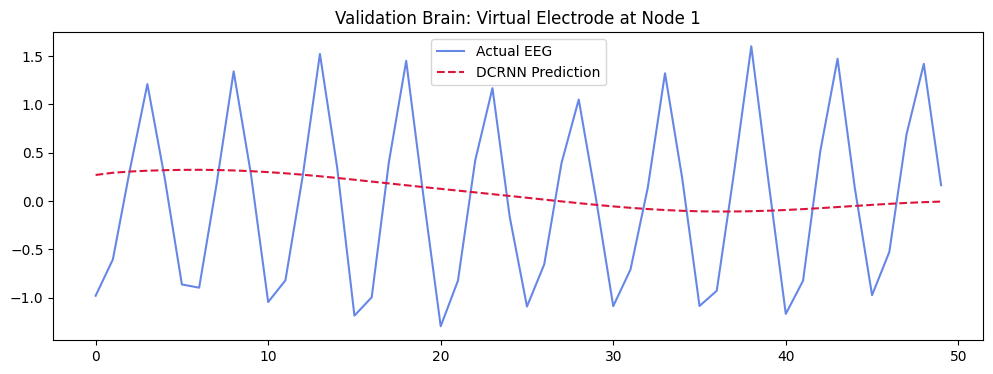

In [28]:
import matplotlib.pyplot as plt

def visual_check(model, loader, device, num_samples=1):
    model.eval()
    with torch.no_grad():
        batch = next(iter(loader))
        x, y = batch['x'].to(device), batch['y'].to(device)
        adj_o, adj_i, mask = batch['adj_out'].to(device), batch['adj_in'].to(device), batch['mask'].to(device)
        
        # Match your training subsampling
        skip = 4
        y_pred = model(x[:, ::skip, :, :], adj_o, adj_i)
        
        for i in range(num_samples):
            held_idx = torch.where(mask[i])[0][0].item() # Get first masked electrode
            
            true_sig = y[i, held_idx, ::skip].cpu().numpy()
            pred_sig = y_pred[i, held_idx, :].cpu().numpy()
            
            plt.figure(figsize=(12, 4))
            plt.plot(true_sig, label="Actual EEG", color='royalblue', alpha=0.8)
            plt.plot(pred_sig, label="DCRNN Prediction", color='crimson', linestyle='--')
            plt.title(f"Validation Brain: Virtual Electrode at Node {held_idx}")
            plt.legend()
            plt.show()

visual_check(model, val_loader, device)

In [99]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader
from torch_geometric.utils import to_dense_adj
from sklearn.neighbors import NearestNeighbors

# ─── Config ───────────────────────────────────────────────────────────────────
win_size = 300
k = 10
hidden_dim = 128
lr = 0.0003
weight_decay = 1e-4 # L2 Regularization to help generalization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class DCRNNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, K=3):
        super().__init__()
        # Layer 1: Input -> Hidden
        self.encoder1 = FixedDCRNN(in_channels, hidden_channels, K)
        # Layer 2: Hidden -> Hidden
        self.encoder2 = FixedDCRNN(hidden_channels, hidden_channels, K)
        
        self.decoder = FixedDCRNN(4, hidden_channels, K)
        self.norm = torch.nn.LayerNorm(hidden_channels)
        self.dropout = torch.nn.Dropout(0.2) # Essential for 2 layers
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, adj_out, adj_in):
        B, T, N, F = x.shape
        locs = x[:, 0, :, 1:]
        h1, h2 = None, None
        
        for t in range(T):
            # Pass through layer 1
            h1 = self.encoder1(x[:, t, :, :], adj_out, adj_in, H=h1)
            # Pass through layer 2 (with a residual connection from h1)
            h2 = self.encoder2(self.dropout(h1), adj_out, adj_in, H=h2)
        
        # Use the deep features for decoding
        h = self.norm(h2)

        outputs = []
        decoder_input = torch.zeros(B, N, 1, device=x.device)
        for t in range(T):
            dec_in = torch.cat([decoder_input, locs], dim=-1)
            h = self.decoder(dec_in, adj_out, adj_in, H=h)
            out = self.lin(h)
            outputs.append(out)
            decoder_input = out
        return torch.stack(outputs, dim=1).squeeze(-1).transpose(1, 2)

# ─── Execution ────────────────────────────────────────────────────────────────
model = DCRNNModel(in_channels=4, hidden_channels=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_func = torch.nn.MSELoss()
# 1. Setup Data
all_patients = list(range(13))
np.random.shuffle(all_patients)

train_p, val_p, test_p = all_patients[:9], all_patients[9:11], all_patients[11:]
graphs = precompute_graphs(all_patients, ecogs_cleaned, xyz_clean, k)

train_loader = DataLoader(ECoGDataset(train_p, ecogs_cleaned, graphs, win_size, 512),
                          batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(ECoGDataset(val_p, ecogs_cleaned, graphs, win_size, 100),
                          batch_size=8, collate_fn=collate_fn)

# 3. Training Loop
history = {'train': [], 'val': []}
for epoch in range(200):
    model.train()
    t_loss = []
    for batch in train_loader:
        optimizer.zero_grad()
        x, y, adj_o, adj_i, mask = batch['x'].to(device), batch['y'].to(device), \
                                   batch['adj_out'].to(device), batch['adj_in'].to(device), \
                                   batch['mask'].to(device)
        '''                           
        edge_mask = (torch.rand_like(adj_o) > 0.20).float()
        adj_o = adj_o * edge_mask
        adj_i = adj_i * edge_mask
        '''
        y_pred = model(x[:, ::2, :, :], adj_o, adj_i) # Subsample time for speed
        loss = loss_func(y_pred[mask], y[:, :, ::2][mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss.append(loss.item())

    model.eval()
    v_loss = []
    with torch.no_grad():
        for batch in val_loader:
            x, y, adj_o, adj_i, mask = batch['x'].to(device), batch['y'].to(device), \
                                       batch['adj_out'].to(device), batch['adj_in'].to(device), \
                                       batch['mask'].to(device)
            # In the training loop, after adj_o is moved to device
            y_pred = model(x[:, ::2, :, :], adj_o, adj_i)
            loss = loss_func(y_pred[mask], y[:, :, ::2][mask])
            v_loss.append(loss.item())

    print(f"Epoch {epoch} | Train: {np.mean(t_loss):.4f} | Val: {np.mean(v_loss):.4f}")

Using device: cpu
Epoch 0 | Train: 0.9973 | Val: 1.0278
Epoch 1 | Train: 0.9955 | Val: 1.0226
Epoch 2 | Train: 0.9980 | Val: 0.9518
Epoch 3 | Train: 1.0032 | Val: 1.0034
Epoch 4 | Train: 0.9931 | Val: 0.9746
Epoch 5 | Train: 1.0000 | Val: 0.9645
Epoch 6 | Train: 1.0034 | Val: 1.0079
Epoch 7 | Train: 0.9989 | Val: 0.9869
Epoch 8 | Train: 0.9946 | Val: 0.9565
Epoch 9 | Train: 0.9989 | Val: 0.9800
Epoch 10 | Train: 1.0021 | Val: 1.0373
Epoch 11 | Train: 0.9992 | Val: 0.9708
Epoch 12 | Train: 0.9899 | Val: 0.9433
Epoch 13 | Train: 0.9941 | Val: 0.9595
Epoch 14 | Train: 0.9970 | Val: 0.9994
Epoch 15 | Train: 0.9860 | Val: 0.9987
Epoch 16 | Train: 0.9815 | Val: 0.9337
Epoch 17 | Train: 0.9984 | Val: 1.0307
Epoch 18 | Train: 0.9869 | Val: 0.9704
Epoch 19 | Train: 0.9844 | Val: 1.0200
Epoch 20 | Train: 0.9878 | Val: 1.0230
Epoch 21 | Train: 0.9751 | Val: 0.9937
Epoch 22 | Train: 0.9726 | Val: 0.9794
Epoch 23 | Train: 0.9809 | Val: 1.0343
Epoch 24 | Train: 0.9716 | Val: 0.9850
Epoch 25 | Train:

KeyboardInterrupt: 

In [ ]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader
from torch_geometric.utils import to_dense_adj
from sklearn.neighbors import NearestNeighbors

# ─── Config ───────────────────────────────────────────────────────────────────
win_size = 50
k = 10
hidden_dim = 64
lr = 0.0005
weight_decay = 1e-4 # L2 Regularization to help generalization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class DCRNNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, K=3):
        super().__init__()
        # Layer 1: Input -> Hidden
        self.encoder1 = FixedDCRNN(in_channels, hidden_channels, K)
        # Layer 2: Hidden -> Hidden
        self.encoder2 = FixedDCRNN(hidden_channels, hidden_channels, K)
        
        self.decoder = FixedDCRNN(4, hidden_channels, K)
        self.norm = torch.nn.LayerNorm(hidden_channels)
        self.dropout = torch.nn.Dropout(0.2) # Essential for 2 layers
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, adj_out, adj_in):
        B, T, N, F = x.shape
        locs = x[:, 0, :, 1:]
        h1, h2 = None, None
        
        for t in range(T):
            # Pass through layer 1
            h1 = self.encoder1(x[:, t, :, :], adj_out, adj_in, H=h1)
            # Pass through layer 2 (with a residual connection from h1)
            h2 = self.encoder2(self.dropout(h1), adj_out, adj_in, H=h2)
        
        # Use the deep features for decoding
        h = self.norm(h2)

        outputs = []
        decoder_input = torch.zeros(B, N, 1, device=x.device)
        for t in range(T):
            dec_in = torch.cat([decoder_input, locs], dim=-1)
            h = self.decoder(dec_in, adj_out, adj_in, H=h)
            out = self.lin(h)
            outputs.append(out)
            decoder_input = out
        return torch.stack(outputs, dim=1).squeeze(-1).transpose(1, 2)

# ─── Execution ────────────────────────────────────────────────────────────────
shortmodel = DCRNNModel(in_channels=4, hidden_channels=hidden_dim).to(device)
optimizer = torch.optim.Adam(shortmodel.parameters(), lr=lr, weight_decay=weight_decay)
loss_func = torch.nn.MSELoss()
# 1. Setup Data
all_patients = list(range(13))
np.random.shuffle(all_patients)

train_p, val_p, test_p = all_patients[:9], all_patients[9:11], all_patients[11:]
graphs = precompute_graphs(all_patients, ecogs_cleaned, xyz_clean, k)

train_loader = DataLoader(ECoGDataset(train_p, ecogs_cleaned, graphs, win_size, 512),
                          batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(ECoGDataset(val_p, ecogs_cleaned, graphs, win_size, 100),
                          batch_size=8, collate_fn=collate_fn)

# 3. Training Loop
history = {'train': [], 'val': []}
for epoch in range(200):
    shortmodel.train()
    t_loss = []
    for batch in train_loader:
        optimizer.zero_grad()
        x, y, adj_o, adj_i, mask = batch['x'].to(device), batch['y'].to(device), \
                                   batch['adj_out'].to(device), batch['adj_in'].to(device), \
                                   batch['mask'].to(device)
        '''                           
        edge_mask = (torch.rand_like(adj_o) > 0.20).float()
        adj_o = adj_o * edge_mask
        adj_i = adj_i * edge_mask
        '''
        y_pred = shortmodel(x[:, ::1, :, :], adj_o, adj_i) # Subsample time for speed
        loss = loss_func(y_pred[mask], y[:, :, ::1][mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss.append(loss.item())

    model.eval()
    v_loss = []
    with torch.no_grad():
        for batch in val_loader:
            x, y, adj_o, adj_i, mask = batch['x'].to(device), batch['y'].to(device), \
                                       batch['adj_out'].to(device), batch['adj_in'].to(device), \
                                       batch['mask'].to(device)
            # In the training loop, after adj_o is moved to device
            y_pred = shortmodel(x[:, ::1, :, :], adj_o, adj_i)
            loss = loss_func(y_pred[mask], y[:, :, ::1][mask])
            v_loss.append(loss.item())

    print(f"Epoch {epoch} | Train: {np.mean(t_loss):.4f} | Val: {np.mean(v_loss):.4f}")

Using device: cpu
Epoch 0 | Train: 0.9757 | Val: 0.9488
Epoch 1 | Train: 0.9585 | Val: 0.9394
Epoch 2 | Train: 0.9516 | Val: 0.9142
Epoch 3 | Train: 0.9503 | Val: 0.9238
Epoch 4 | Train: 0.9445 | Val: 0.9245
Epoch 5 | Train: 0.9374 | Val: 0.8597
Epoch 6 | Train: 0.9175 | Val: 0.8659
Epoch 7 | Train: 0.9086 | Val: 0.8847
Epoch 8 | Train: 0.8992 | Val: 0.8671
Epoch 9 | Train: 0.8926 | Val: 0.8564
Epoch 10 | Train: 0.8551 | Val: 0.9818
Epoch 11 | Train: 0.9176 | Val: 0.8549
Epoch 12 | Train: 0.8955 | Val: 0.8368
Epoch 13 | Train: 0.8837 | Val: 0.8567
Epoch 14 | Train: 0.8571 | Val: 0.8337
Epoch 15 | Train: 0.8796 | Val: 0.8361
Epoch 16 | Train: 0.8564 | Val: 0.8396
Epoch 17 | Train: 0.8992 | Val: 0.8369
Epoch 18 | Train: 0.8850 | Val: 0.8258
Epoch 19 | Train: 0.8881 | Val: 0.8714
Epoch 20 | Train: 0.8653 | Val: 0.8192
Epoch 21 | Train: 0.8147 | Val: 0.8464
Epoch 22 | Train: 0.8411 | Val: 0.8273
Epoch 23 | Train: 0.8400 | Val: 0.8310
Epoch 24 | Train: 0.8927 | Val: 0.7723
Epoch 25 | Train: